# FNQS training basics
---

A Foundation NQS (FNQS) is a single neural network $\psi(\sigma; \lambda)$ trained simultaneously over a family of Hamiltonians $H(\lambda)$ parameterised by a coupling $\lambda$. Rather than retraining from scratch at every $\lambda$, a single optimisation run produces a variational state valid across the full parameter range.

This tutorial covers:

1. Setting up the FNQS building blocks: `ParameterSpace`, `FoundationalQuantumState`, `ParametrizedOperator`
2. Training with the natural-gradient VMC driver `VMC_NG`
3. Post-training energy and magnetisation sweep via importance sampling
4. Quantum Fisher information $\chi(h)$ via IS reweighting

For the IS theory and the ESS diagnostic see **[Tutorial 3 – Importance Sampling](3.%20Importance%20Sampling.ipynb)**.

In [1]:
import os
os.environ["NETKET_EXPERIMENTAL_SHARDING"] = "1"
os.environ.setdefault("JAX_PLATFORM_NAME", "cpu")

import time
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

import netket as nk
import netket_foundation as nkf
from netket_foundation._src.model.vit import ViTFNQS
from netket_foundation.expectation_value import expect_is, qfi_is

∣NK⟩ Tip: Avoid LocalOperator with have N-body operators (N>4). PauliStrings is ok.

## System: 1D transverse-field Ising chain
---

$$
\hat H(h) = -\sum_{i=1}^L \sigma^z_i \sigma^z_{i+1} - h \sum_{i=1}^L \sigma^x_i,
\qquad \sigma^\alpha_{L+1} = \sigma^\alpha_1
$$

with $L = 10$ spins, periodic boundary conditions, and $h \in [0.75, 2.0]$. The quantum phase transition occurs at $h_c = 1$.

In [2]:
L     = 10
hi    = nk.hilbert.Spin(0.5, L)
graph = nk.graph.Chain(L, pbc=True)

ps = nkf.ParameterSpace(N=1, min=0.75, max=2.0)

def create_operator(params):
    assert params.shape == (1,)
    h     = params[0]
    ha_X  = sum(nkf.operator.sigmax(hi, i) for i in range(L))
    ha_ZZ = sum(
        nkf.operator.sigmaz(hi, i) @ nkf.operator.sigmaz(hi, (i + 1) % L)
        for i in range(L)
    )
    return -h * ha_X - ha_ZZ

ha_p = nkf.operator.ParametrizedOperator(hi, ps, create_operator)

Mz  = sum(nkf.operator.sigmaz(hi, i) for i in range(L)) * (1.0 / L)
Mz2 = Mz @ Mz

print(f"System: 1D Ising, L={L}, h in [{ps._min}, {ps._max}]")

System: 1D Ising, L=10, h in [0.75, 2.0]


## FNQS building blocks
---

Three objects extend the standard NetKet workflow:

- **`ParameterSpace`** — defines the range and dimension of the Hamiltonian parameter $h$.
- **`ParametrizedOperator`** — wraps `create_operator` so the driver evaluates it with per-replica parameters at every step.
- **`FoundationalQuantumState`** — samples physical configurations jointly with $n_\text{replicas}$ parameter values. Each replica group of Markov chains is pinned to a different $h$.

In [3]:
import optax

ma = ViTFNQS(
    num_layers=2,
    d_model=12,
    heads=4,
    L_eff=L // 2,
    n_coups=ps.size,
    b=2,
    complex=False,
    disorder=False,
    transl_invariant=True,
    two_dimensional=False,
)

sa = nk.sampler.MetropolisLocal(hi, n_chains=256)
vs = nkf.FoundationalQuantumState(sa, ma, ps, n_samples=1024, n_replicas=8, seed=1)

# Distribute replicas uniformly across [0.75, 2.0].
vs.parameter_array = jnp.linspace(0.75, 2.0, vs.n_replicas).reshape(-1, 1)

print(f"Parameters: {vs.n_parameters}")
print(f"Replicas: {vs.n_replicas},  samples: {vs.n_samples}")

Parameters: 3412
Replicas: 8,  samples: 1024


## Training
---

`VMC_NG` is a natural-gradient VMC driver that handles the replica dimension. The diagonal shift $\varepsilon$ decays exponentially to prevent early convergence to a poor minimum.

In [ ]:
diag_shift = optax.exponential_decay(1e-2, transition_steps=32, decay_rate=0.5)
optimizer  = optax.sgd(0.01)
gs = nkf.VMC_NG(ha_p, optimizer, variational_state=vs, diag_shift=diag_shift)

t0 = time.perf_counter()
gs.run(512, show_progress=True)
print(f"Training done in {time.perf_counter() - t0:.0f} s")

online_statistics: chain_length=4, exponential moving average window: 50, decay=0.920


  0%|          | 0/300 [00:00<?, ?it/s]

## Post-training evaluation
---

After training, `vs.get_state(h0)` extracts an `MCState` for any $h_0$ without retraining. To sweep a fine grid without running full MCMC at every point we use IS from a small set of anchor states — see **Tutorial 3** for the theory and ESS diagnostic.

In [ ]:
h_anchors = np.linspace(0.8, 1.9, 7)
h_sweep   = np.linspace(0.75, 2.0, 51)

# Full MCMC at anchor points only.
anchor_states = {}
for h0 in h_anchors:
    mc = vs.get_state(jnp.array([h0]))
    mc.n_samples = 4096
    for _ in range(8):
        mc.sample()
    anchor_states[h0] = mc

def nearest_anchor(h, anchors=h_anchors):
    return anchors[np.argmin(np.abs(anchors - h))]

# IS sweep for energy and magnetisation.
is_E, is_E_err, is_Mz2, is_Mz2_err, is_ess = [], [], [], [], []

for h0 in h_sweep:
    mc_ref   = anchor_states[nearest_anchor(h0)]
    pars     = jnp.array([h0])
    tgt_vars = vs.get_state(pars).variables

    r_E   = expect_is(create_operator(pars), mc_ref, tgt_vars)
    r_Mz2 = expect_is(Mz2, mc_ref, tgt_vars)

    is_E.append(float(r_E.stats.mean.real))
    is_E_err.append(float(r_E.stats.error_of_mean))
    is_Mz2.append(float(r_Mz2.stats.mean.real))
    is_Mz2_err.append(float(r_Mz2.stats.error_of_mean))
    is_ess.append(r_E.ess_fraction)

is_E       = np.array(is_E)
is_Mz2     = np.array(is_Mz2)
is_E_err   = np.array(is_E_err)
is_Mz2_err = np.array(is_Mz2_err)
print(f"IS sweep: {len(h_sweep)} points, {len(h_anchors)} anchors.")

IS sweep: 51 points, 7 anchors.


In [ ]:
# Exact diagonalisation using the same operators as training (no convention mismatch).
Mz2_sp = Mz2.to_sparse()

ed_E, ed_Mz2 = [], []
for h0 in h_sweep:
    H_h = create_operator(jnp.array([h0]))
    E0, psi0 = nk.exact.lanczos_ed(H_h, k=1, compute_eigenvectors=True)
    psi0 = psi0.reshape(-1)
    ed_E.append(float(E0[0]))
    ed_Mz2.append(float(np.real(psi0.conj() @ (Mz2_sp @ psi0))))

ed_E   = np.array(ed_E)
ed_Mz2 = np.array(ed_Mz2)
print("ED done.")

ED done.


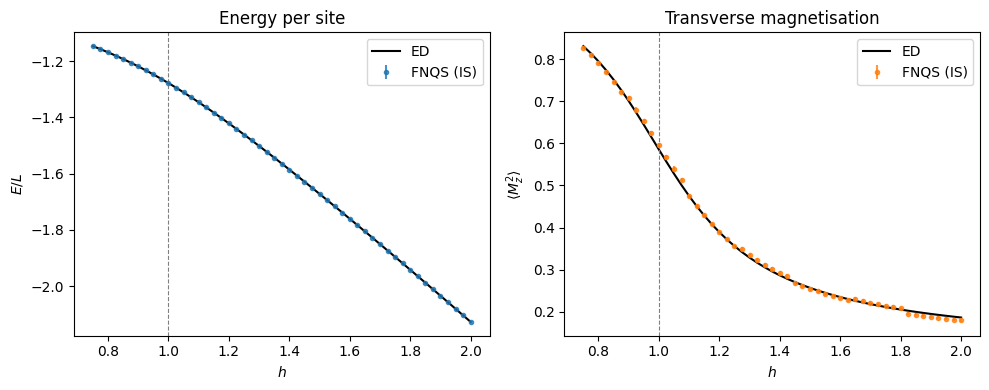

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ax = axes[0]
ax.plot(h_sweep, ed_E / L, "k-", lw=1.5, label="ED")
ax.errorbar(h_sweep, is_E / L, yerr=is_E_err / L, fmt="o", ms=3,
            color="tab:blue", label="FNQS (IS)", alpha=0.8)
ax.axvline(1.0, ls="--", color="gray", lw=0.8)
ax.set_xlabel("$h$")
ax.set_ylabel("$E / L$")
ax.set_title("Energy per site")
ax.legend()

ax = axes[1]
ax.plot(h_sweep, ed_Mz2, "k-", lw=1.5, label="ED")
ax.errorbar(h_sweep, is_Mz2, yerr=is_Mz2_err, fmt="o", ms=3,
            color="tab:orange", label="FNQS (IS)", alpha=0.8)
ax.axvline(1.0, ls="--", color="gray", lw=0.8)
ax.set_xlabel("$h$")
ax.set_ylabel(r"$\langle M_z^2 \rangle$")
ax.set_title("Transverse magnetisation")
ax.legend()

plt.tight_layout()
plt.show()

## Quantum Fisher information via IS
---

The fidelity susceptibility with respect to $h$ is

$$
\chi(h) = \mathrm{Var}_{|\psi(h)|^2}\!\left[\partial_h \log\psi(\sigma;\,h)\right]
         = \bigl\langle (\partial_h \log\psi)^2\bigr\rangle
           - \bigl\langle \partial_h \log\psi\bigr\rangle^2.
$$

It peaks at the quantum phase transition ($h_c = 1$ in the thermodynamic limit) and measures how rapidly the ground-state manifold curves as $h$ varies. We compute it via IS: reuse the nearest anchor's samples with IS weights, then evaluate the weighted variance of $\partial_h\log\psi$ using `jax.jacfwd`.

In [ ]:
qfi_vals = []
for h0 in h_sweep:
    result = qfi_is(vs, jnp.array([h0]), anchor_states[nearest_anchor(h0)])
    qfi_vals.append(float(result.chi[0, 0]))

qfi_vals = np.array(qfi_vals)
print(f"QFI sweep done. Peak at h = {h_sweep[np.argmax(qfi_vals)]:.2f}")

QFI sweep done. Peak at h = 0.93


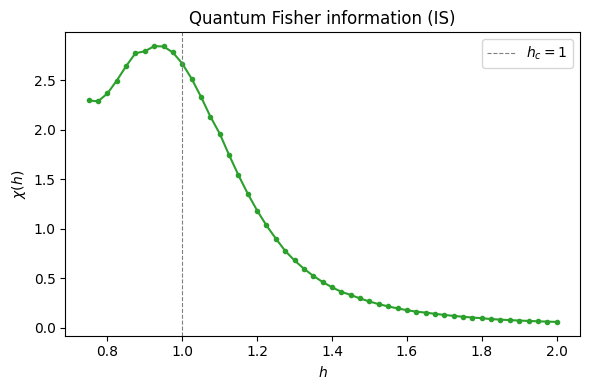

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(h_sweep, qfi_vals, "-o", ms=3, color="tab:green")
ax.axvline(1.0, ls="--", color="gray", lw=0.8, label="$h_c = 1$")
ax.set_xlabel("$h$")
ax.set_ylabel(r"$\chi(h)$")
ax.set_title("Quantum Fisher information (IS)")
ax.legend()

plt.tight_layout()
plt.show()